In [122]:
import pandas as pd
import numpy as np

In [123]:
data = pd.read_csv('data/corona_tested_individuals_ver_006.csv')
df = data[data['corona_result']!='other']
df = df.drop(columns='test_date')

/var/folders/83/rc8yjjxj1nsdr_jvgcktc89h0000gn/T/ipykernel_65508/1434022705.py:1: DtypeWarning: Columns (0: age_60_and_above) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/corona_tested_individuals_ver_006.csv')


In [124]:
for col in df.columns:
    print(df[col].unique())

[ 0.  1. nan]
[ 0.  1. nan]
[ 0.  1. nan]
[ 0.  1. nan]
[ 0.  1. nan]
<StringArray>
['negative', 'positive']
Length: 2, dtype: str
<StringArray>
[nan, 'Yes', 'No']
Length: 3, dtype: str
<StringArray>
['female', 'male', nan]
Length: 3, dtype: str
<StringArray>
['Other', 'Abroad', 'Contact with confirmed']
Length: 3, dtype: str


In [125]:
df.head()

,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other


In [126]:
df.corona_result.value_counts(normalize=True)

corona_result
negative    0.946431
positive    0.053569
Name: proportion, dtype: float64

In [127]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['corona_result'])
for col in X.columns:
    X[col] = X[col].astype(str)
    X[col] = X[col].fillna('none')
y = df['corona_result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24,stratify=y)


In [128]:
X.info()

<class 'pandas.DataFrame'>
Index: 274956 entries, 0 to 278847
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   cough                274956 non-null  str  
 1   fever                274956 non-null  str  
 2   sore_throat          274956 non-null  str  
 3   shortness_of_breath  274956 non-null  str  
 4   head_ache            274956 non-null  str  
 5   age_60_and_above     274956 non-null  str  
 6   gender               274956 non-null  str  
 7   test_indication      274956 non-null  str  
dtypes: str(8)
memory usage: 18.9 MB


In [129]:
from catboost import CatBoostClassifier
cb_model = CatBoostClassifier()

cat_features = X.columns.tolist()

cb_model.fit(X_train, y_train,cat_features=cat_features)
y_pred = cb_model.predict(X_test)
y_prob = cb_model.predict_proba(X_test)

Learning rate set to 0.103067
0:	learn: 0.5426683	total: 83.1ms	remaining: 1m 23s
1:	learn: 0.4340776	total: 150ms	remaining: 1m 15s
2:	learn: 0.3541314	total: 196ms	remaining: 1m 5s
3:	learn: 0.2989078	total: 239ms	remaining: 59.5s
4:	learn: 0.2578690	total: 311ms	remaining: 1m 1s
5:	learn: 0.2284127	total: 367ms	remaining: 1m
6:	learn: 0.2078069	total: 434ms	remaining: 1m 1s
7:	learn: 0.1889538	total: 506ms	remaining: 1m 2s
8:	learn: 0.1750358	total: 554ms	remaining: 1m
9:	learn: 0.1641323	total: 616ms	remaining: 1m 1s
10:	learn: 0.1563663	total: 666ms	remaining: 59.8s
11:	learn: 0.1504969	total: 730ms	remaining: 1m
12:	learn: 0.1448133	total: 797ms	remaining: 1m
13:	learn: 0.1404756	total: 854ms	remaining: 1m
14:	learn: 0.1355092	total: 937ms	remaining: 1m 1s
15:	learn: 0.1316816	total: 1s	remaining: 1m 1s
16:	learn: 0.1287447	total: 1.09s	remaining: 1m 2s
17:	learn: 0.1252069	total: 1.17s	remaining: 1m 3s
18:	learn: 0.1220983	total: 1.24s	remaining: 1m 4s
19:	learn: 0.1196743	total

In [130]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.98      0.99      0.98     52046
    positive       0.80      0.59      0.68      2946

    accuracy                           0.97     54992
   macro avg       0.89      0.79      0.83     54992
weighted avg       0.97      0.97      0.97     54992



<Axes: >

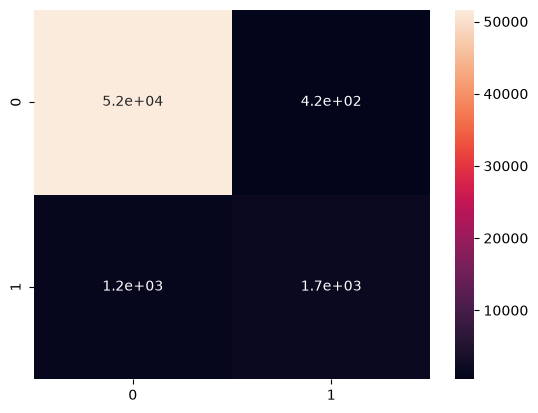

In [131]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)


In [139]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:,1], pos_label='positive')

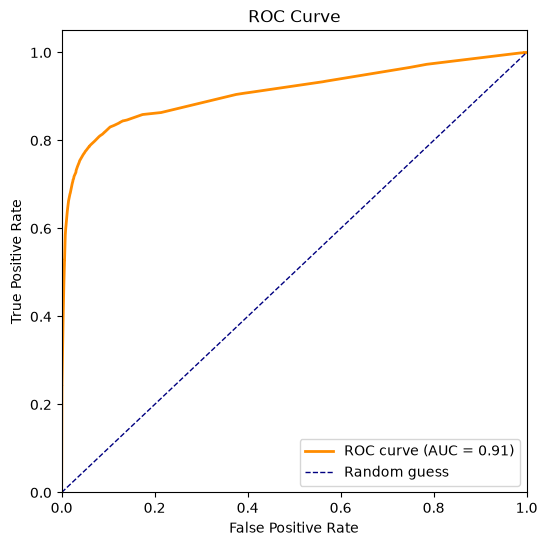

In [140]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()